In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from uncertainties import ufloat, correlated_values
import uncertainties.unumpy as unp

Ny=3, min g^2=4.75
Ny=4, min g^2=4.75
Ny=5, min g^2=4.75
Ny=6, min g^2=4.75
Ny=7, min g^2=5.0
Ny=8, min g^2=5.0
Ny=9, min g^2=5.0
Ny=10, min g^2=5.0
Ny=11, min g^2=5.0
Ny=12, min g^2=5.0


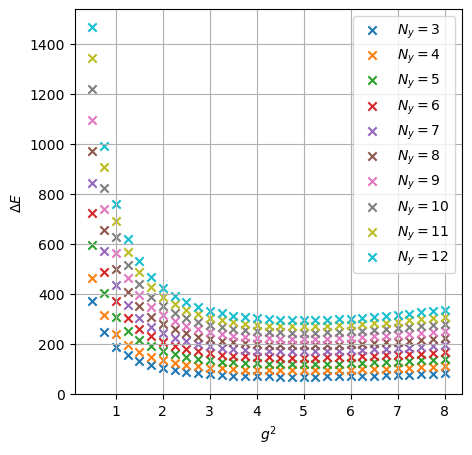

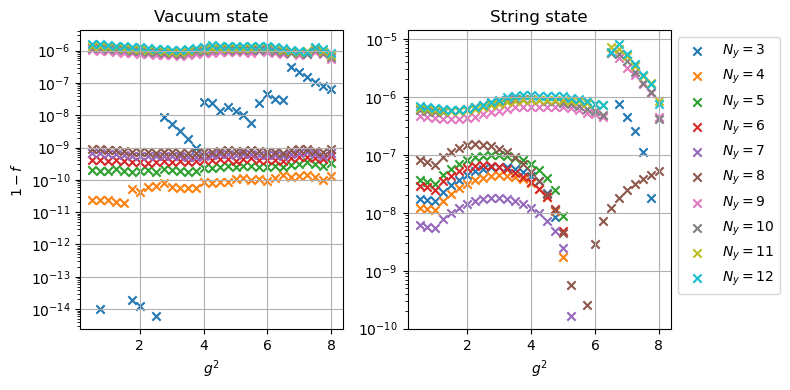

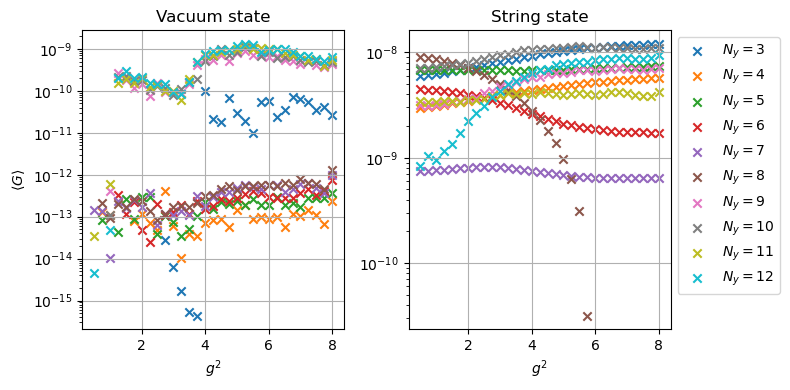

In [4]:
Nx = 4
Ny = np.arange(3, 13, 1)
Ny_fit_filter = Ny > 3
Ny_fit_filter_excluded = Ny > 4
r = Ny

g2 = np.loadtxt("NX4/ground/AAA_g2_4x3.txt")

Estring = []
Eground = []
fstring = []
fground = []
Gstring = []
Gground = []
massgaps = np.loadtxt("ed_code/ed_4x4_periodic/massgaps.txt")

for y in Ny:
    Eground.append(np.loadtxt(f"NX4/ground/AAA_E_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/ground/AAA_E_{Nx}x{y}.txt"))
    Estring.append(np.loadtxt(f"NX4/string/AAA_E_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/string/AAA_E_{Nx}x{y}.txt"))
    fground.append(np.loadtxt(f"NX4/ground/AAA_variance_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/ground/AAA_variance_{Nx}x{y}.txt") / massgaps**2)
    fstring.append(np.loadtxt(f"NX4/string/AAA_variance_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/string/AAA_variance_{Nx}x{y}.txt") / massgaps**2)
    gauss_ground = np.loadtxt(f"NX4/ground/AAA_gauss_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/ground/AAA_gauss_{Nx}x{y}.txt")
    gauss_string = np.loadtxt(f"NX4/string/AAA_gauss_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/string/AAA_gauss_{Nx}x{y}.txt")
    closed_bottom_ground = np.loadtxt(f"NX4/ground/AAA_closed_bottom_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/ground/AAA_closed_bottom_{Nx}x{y}.txt")
    closed_bottom_string = np.loadtxt(f"NX4/string/AAA_closed_bottom_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/string/AAA_closed_bottom_{Nx}x{y}.txt")
    closed_top_ground = np.loadtxt(f"NX4/ground/AAA_closed_top_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/ground/AAA_closed_top_{Nx}x{y}.txt")
    closed_top_string = np.loadtxt(f"NX4/string/AAA_closed_top_{Nx}x{y}.txt" if y > 8 or y == 3 else f"4xN_prec/string/AAA_closed_top_{Nx}x{y}.txt")
    Gground.append(gauss_ground + closed_bottom_ground + closed_top_ground)
    Gstring.append(gauss_string + closed_bottom_string + closed_top_string)

Eground = np.array(Eground)
Estring = np.array(Estring)
fground = np.array(fground)
fstring = np.array(fstring)
Gground = np.array(Gground)
Gstring = np.array(Gstring)

V = Estring - Eground

def cornell(r, gamma, sigma, c):
    return gamma / r + sigma * r + c

def simplified(r, sigma, c):
    return sigma * r + c

plt.figure(figsize=(5,5))
plt.xlabel(r"$g^2$")
plt.ylabel(r"$\Delta E$")

for i, y in enumerate(Ny):
    print(f"Ny={y}, min g^2={g2[np.argmin(V[i])]}")
    plt.scatter(g2, V[i], marker='x', label=r"$N_y={}$".format(y))

plt.grid()
plt.legend()
plt.savefig("potential.png", dpi=300)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].set_title("Vacuum state")
ax[0].set_xlabel(r"$g^2$")
ax[0].set_ylabel(r"$1-f$")
ax[0].set_yscale("log")
ax[0].grid()
for i, y in enumerate(Ny):
    ax[0].scatter(g2, fground[i], marker='x', label=r"$N_y={}$".format(y))

#ax[0].legend()

ax[1].set_title("String state")
ax[1].set_xlabel(r"$g^2$")
#ax[1].set_ylabel(r"$1-f$")
ax[1].set_yscale("log")
ax[1].grid()
for i, y in enumerate(Ny):
    ax[1].scatter(g2, fstring[i], marker='x', label=r"$N_y={}$".format(y))

ax[1].legend(bbox_to_anchor=(1, 1))

fig.tight_layout()
fig.savefig("fidelity.png", dpi=300)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].set_title("Vacuum state")
ax[0].set_xlabel(r"$g^2$")
ax[0].set_ylabel(r"$\langle G\rangle$")
ax[0].set_yscale("log")
ax[0].grid()
for i, y in enumerate(Ny):
    ax[0].scatter(g2, Gground[i], marker='x', label=r"$N_y={}$".format(y))

#ax[0].legend()

ax[1].set_title("String state")
ax[1].set_xlabel(r"$g^2$")
#ax[1].set_ylabel(r"$1-f$")
ax[1].set_yscale("log")
ax[1].grid()
for i, y in enumerate(Ny):
    ax[1].scatter(g2, Gstring[i], marker='x', label=r"$N_y={}$".format(y))

ax[1].legend(bbox_to_anchor=(1, 1))
fig.tight_layout()
fig.savefig("gauss.png", dpi=300)

In [ ]:
gamma = []
sigma = []
c = []
dVrel = []

gamma_excluded = []
sigma_excluded= []
c_excluded = []
dVrel_excluded = []

def gen_potentials(Ny_filter, gamma, sigma, c, dVrel, save=False):
    for i, g in enumerate(g2):
        opt, cov = sp.optimize.curve_fit(cornell, Ny[Ny_filter], V[Ny_filter,i])
        # chi2 = np.sum(((V[:,i] - cornell(Ny, *opt)) / (V[:,i] * dVrel))**2) / dof = 1
        # => dVrel = np.sqrt(np.sum(((V[:,i] - cornell(Ny, *opt)) / V[:,i])**2) / dof)
        dof = len(Ny[1:]) - len(opt)
        dV = (np.sum(((V[Ny_filter,i] - cornell(Ny[Ny_filter], *opt)) / V[Ny_filter,i])**2) / dof)**0.5
        dVrel.append(dV)

        Ny_fit = np.linspace(2, 13, 1000)
        uopt = correlated_values(opt, cov)
        gamma.append(uopt[0])
        sigma.append(uopt[1])
        c.append(uopt[2])

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].set_title(fr"$\Delta E, g^2={round(g, 2)}$")
        ax[0].errorbar(Ny, V[:,i], dV * V[:,i], fmt='x')
        ax[0].plot(Ny_fit, cornell(Ny_fit, *opt))
        ax[0].grid()

        ax[1].set_title(r"$\Delta E-\sigma N_y-c, g^2={" + str(round(g, 2)) + "}$")
        ax[1].errorbar(Ny, V[:,i] - simplified(Ny, opt[1], opt[2]), dV * np.abs(V[:,i]), fmt='x')
        ax[1].plot(Ny_fit, cornell(Ny_fit, *opt) - simplified(Ny_fit, opt[1], opt[2]))
        ax[1].grid()

        ax[2].set_title(r"$\Delta E-V, g^2={" + str(round(g, 2)) + "}$")
        ax[2].errorbar(Ny, V[:,i] - cornell(Ny, *opt), dV * np.abs(V[:,i]), fmt='x')
        ax[2].plot(Ny_fit, [0] * len(Ny_fit))
        ax[2].grid()
        fig.tight_layout()

        if save:
            fig.savefig(f"NX4/images/V_g2_{round(g, 2)}.png")

        plt.close(fig)

gen_potentials(Ny_fit_filter, gamma, sigma, c, dVrel)
gen_potentials(Ny_fit_filter_excluded, gamma_excluded, sigma_excluded, c_excluded, dVrel_excluded)

gamma = np.array(gamma)
sigma = np.array(sigma)
c = np.array(c)
dVrel = np.array(dVrel)

gamma_excluded = np.array(gamma_excluded)
sigma_excluded = np.array(sigma_excluded)
c_excluded = np.array(c_excluded)
dVrel_excluded = np.array(dVrel_excluded)

def save_potential_params(path, gamma, sigma, c, dVrel):
    with open(path, "w") as f:
        print(r"\begin{table}[!hb]", file=f)
        print(r"\centering", file=f)
        print(r"\begin{tabular}{lllll}", file=f)
        print(r"    $\mathbf{g^2}$ & $\mathbf{\gamma}$ & $\mathbf{\sigma}$ & $\mathbf{c}$ & $\mathbf{\Delta V/V}$ \\ \hline", file=f)

        for i, _g2 in enumerate(g2):
            print(rf"   {round(_g2, 2)} & {gamma[i]:fS} & {sigma[i]:fS} & {c[i]:fS} & {dVrel[i]:.2f} \\", file=f)

        print(r"\end{tabular}", file=f)
        print(r"\caption{Fit parameters for Cornell potential}", file=f)
        print(r"\end{table}", file=f)

save_potential_params("potential-params.tex", gamma, sigma, c, dVrel)
save_potential_params("potential-params-excluded.tex", gamma_excluded, sigma_excluded, c_excluded, dVrel_excluded)

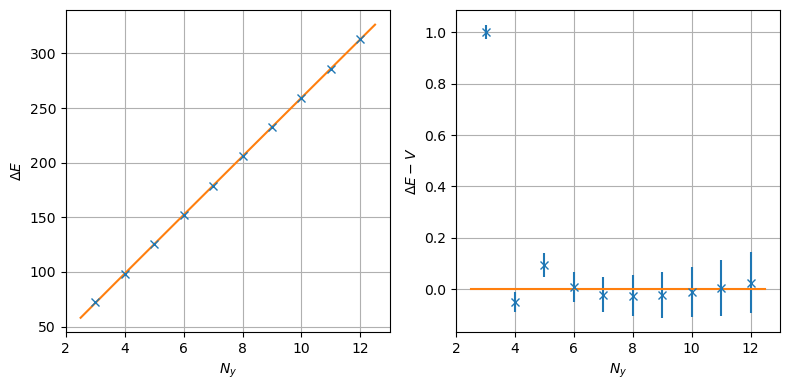

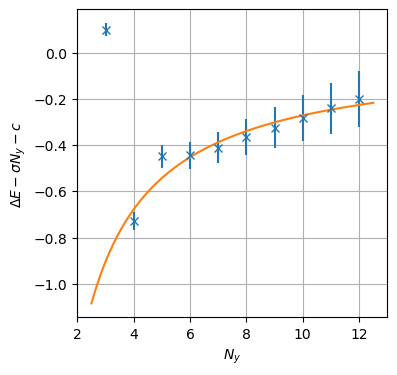

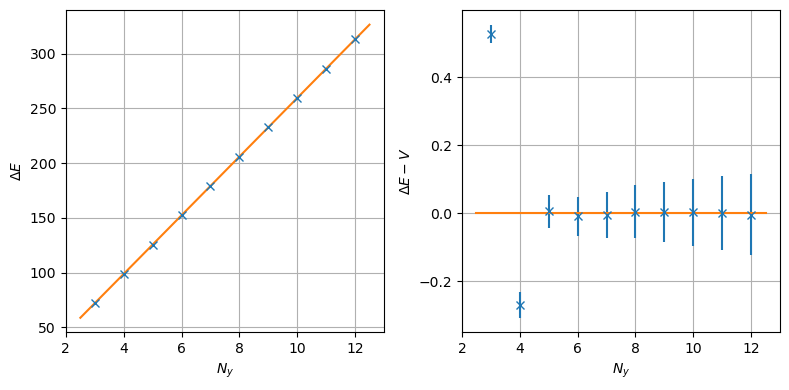

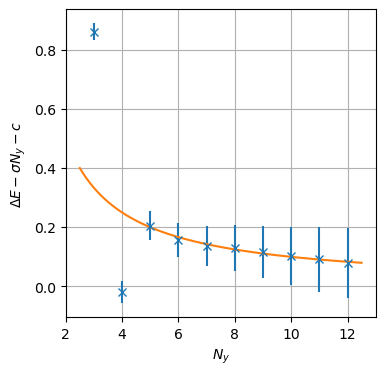

In [10]:
i = np.argwhere(g2 == 3.5)[0][0]
Ny_fit = np.linspace(2.5, 12.5, 1000)
opt = (gamma[i].nominal_value, sigma[i].nominal_value, c[i].nominal_value)
opt_excluded = (gamma_excluded[i].nominal_value, sigma_excluded[i].nominal_value, c_excluded[i].nominal_value)

def save_potential_example(postfix, opt):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].set_xlabel(r"$N_y$")
    ax[0].set_ylabel(r"$\Delta E$")
    ax[0].errorbar(Ny, V[:,i], dVrel[i] * V[:,i], fmt='x')
    ax[0].plot(Ny_fit, cornell(Ny_fit, *opt))
    ax[0].grid()

    ax[1].set_xlabel(r"$N_y$")
    ax[1].set_ylabel(r"$\Delta E-V$")
    ax[1].errorbar(Ny, V[:,i] - cornell(Ny, *opt), dVrel[i] * np.abs(V[:,i]), fmt='x')
    ax[1].plot(Ny_fit, [0] * len(Ny_fit))
    ax[1].grid()
    fig.tight_layout()
    fig.savefig(f"NX4/images/cornell-fit{postfix}.png")

    plt.figure(figsize=(4, 4))
    plt.xlabel(r"$N_y$")
    plt.ylabel(r"$\Delta E-\sigma N_y-c$")
    plt.errorbar(Ny, V[:,i] - simplified(Ny, opt[1], opt[2]), dVrel[i] * np.abs(V[:,i]), fmt='x')
    plt.plot(Ny_fit, cornell(Ny_fit, *opt) - simplified(Ny_fit, opt[1], opt[2]))
    plt.grid()
    plt.savefig(f"NX4/images/cornell-luescher{postfix}.png")

save_potential_example("", opt)
save_potential_example("-excluded", opt_excluded)

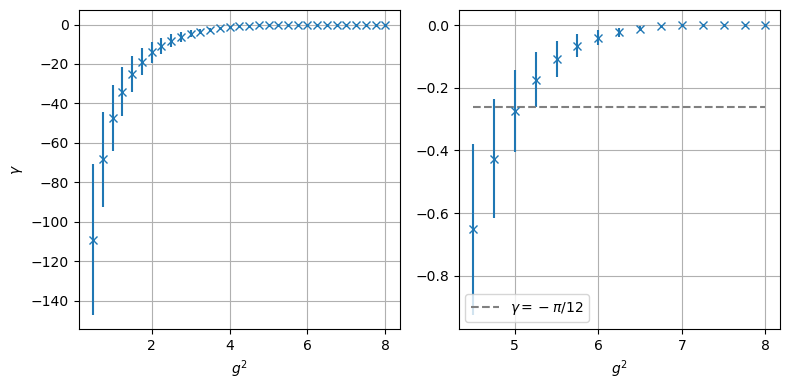

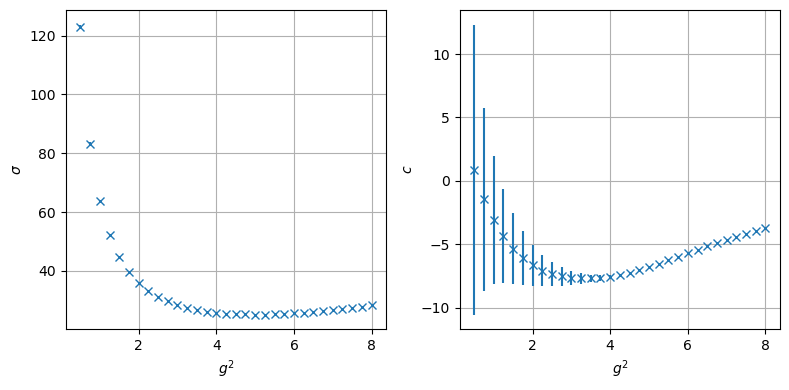

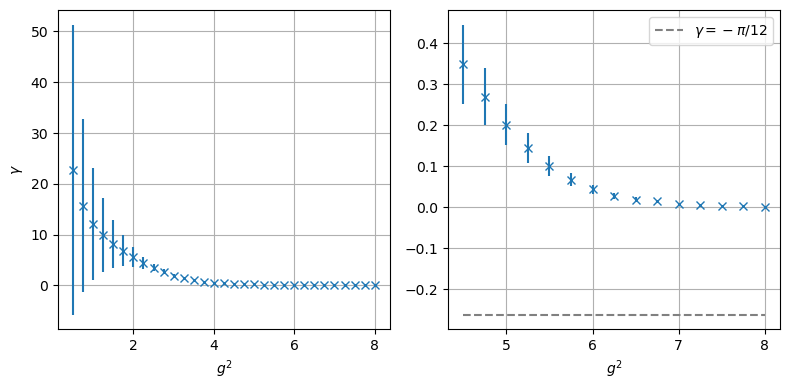

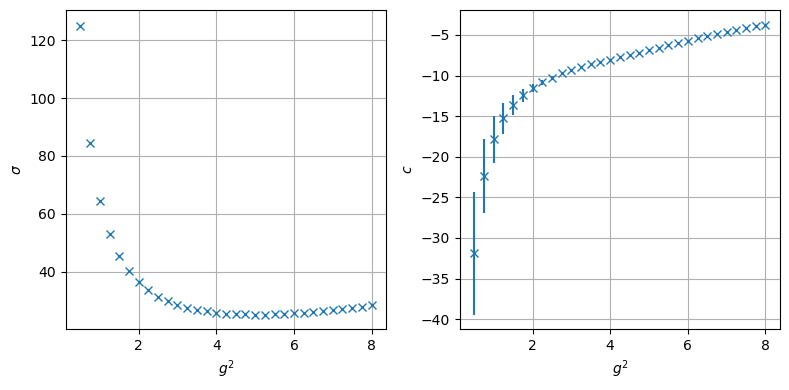

In [11]:
def save_terms(postfix, gamma, sigma, c):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].set_xlabel(r"$g^2$")
    ax[0].set_ylabel(r"$\gamma$")
    #ax[0].yscale("log")
    ax[0].errorbar(g2, unp.nominal_values(gamma), unp.std_devs(gamma), fmt='x')
    ax[0].grid()

    ax[1].set_xlabel(r"$g^2$")
    #ax[1].yscale("log")
    ax[1].errorbar(g2[:-16], unp.nominal_values(gamma[:-16]), unp.std_devs(gamma[:-16]), fmt='x')
    #ax[1].plot([5.425]*2, [-0.9, 0], ls='--', color='gray')
    ax[1].plot([4.5, 8], [-np.pi/12]*2, ls='--', color='gray', label=r"$\gamma=-\pi/12$")
    ax[1].grid()
    ax[1].legend()
    fig.tight_layout()
    fig.savefig(f"gamma{postfix}.png", dpi=300)

    #def gamma_theo(x, a, b):
    #    return a * x**b

    #opt, cov = sp.optimize.curve_fit(gamma_theo, g2, unp.nominal_values(gamma), sigma=unp.std_devs(gamma), absolute_sigma=True, p0=(0, -1))
    #print(unp.uarray(opt, np.diag(cov)**0.5))

    #gamma_fit = np.linspace(0.25, 9, 1000)
    #plt.plot(gamma_fit, gamma_theo(gamma_fit, *opt))

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].set_xlabel(r"$g^2$")
    ax[0].set_ylabel(r"$\sigma$")
    ax[0].errorbar(g2, unp.nominal_values(sigma), unp.std_devs(sigma), fmt='x')
    ax[0].grid()

    ax[1].set_xlabel(r"$g^2$")
    ax[1].set_ylabel(r"$c$")
    ax[1].errorbar(g2, unp.nominal_values(c), unp.std_devs(c), fmt='x')
    ax[1].grid()
    fig.tight_layout()
    fig.savefig(f"sigma-c{postfix}.png", dpi=300)

save_terms("", gamma, sigma, c)
save_terms("-excluded", gamma_excluded, sigma_excluded, c_excluded)

In [12]:

#g2 = np.loadtxt(f"Nx4/string/AAA_g2_4x12.txt")
w = np.zeros((len(g2), len(Ny), Nx+1))

#g2_index = np.where(np.abs(g2 - g2_target) < 1e-5)[0]

#assert(len(g2_index) == 1)
#g2_index = g2_index[0]
for i, _Ny in enumerate(Ny):
    
    Ex = []
    for j in range(4):
        Ex_g2 = np.loadtxt(f"Nx4/string/AAA_ex{j}_{Nx}x{_Ny}.txt" if _Ny > 8 or _Ny == 3 else f"4xN_prec/string/AAA_ex{j}_{Nx}x{_Ny}.txt").reshape((-1,_Ny,Nx))
        Ex.append(Ex_g2)

    for j in range(len(g2)):
        if _Ny % 2 == 0:
            w[j,i,0] = Ex[1][j,_Ny//2  ,0] + Ex[2][j,_Ny//2  ,0]
            w[j,i,1] = Ex[1][j,_Ny//2-1,1] + Ex[3][j,_Ny//2-1,1]
            w[j,i,2] = Ex[1][j,_Ny//2  ,2] + Ex[2][j,_Ny//2  ,2]
            w[j,i,3] = Ex[1][j,_Ny//2-1,3] + Ex[3][j,_Ny//2-1,3]
            w[j,i,4] = Ex[1][j,_Ny//2  ,0] + Ex[2][j,_Ny//2  ,0]
        else:
            w[j,i,0] = Ex[1][j,_Ny//2,0] + Ex[3][j,_Ny//2,0]
            w[j,i,1] = Ex[1][j,_Ny//2,1] + Ex[2][j,_Ny//2,1]
            w[j,i,2] = Ex[1][j,_Ny//2,2] + Ex[3][j,_Ny//2,2]
            w[j,i,3] = Ex[1][j,_Ny//2,3] + Ex[2][j,_Ny//2,3]
            w[j,i,4] = Ex[1][j,_Ny//2,0] + Ex[3][j,_Ny//2,0]

x = (np.arange(0, Nx+1, 1) - 2) * 3/2
def gauss(x, A, omega, c):
    return A * np.exp(-x**2/(2*omega**2)) + c

def gauss_compact(x, A, omega, c):
    return np.where(np.abs(x) < 2*omega, A * np.exp(-2*x**2/(4*omega**2-x**2)) + c, c * np.ones_like(x) )

A = np.zeros((len(g2), len(Ny)), dtype=object)
omega = np.zeros((len(g2), len(Ny)), dtype=object)
c = np.zeros((len(g2), len(Ny)), dtype=object)

A_compact = np.zeros((len(g2), len(Ny)), dtype=object)
omega_compact = np.zeros((len(g2), len(Ny)), dtype=object)
c_compact = np.zeros((len(g2), len(Ny)), dtype=object)

for i, _w_g2 in enumerate(w):

    for j, _w in enumerate(_w_g2):
        opt, cov = sp.optimize.curve_fit(gauss, x, _w, bounds=[(0, 0, -np.inf), (np.inf, np.inf, np.inf)])
        A[i,j], omega[i,j], c[i,j] = correlated_values(opt, cov)

        opt, cov = sp.optimize.curve_fit(gauss_compact, x, _w, bounds=[(0, 0, -np.inf), (np.inf, np.inf, np.inf)])
        A_compact[i,j], omega_compact[i,j], c_compact[i,j] = correlated_values(opt, cov)


for i, _w_g2 in enumerate(w):
    for j, _w in enumerate(_w_g2):
        plt.figure(figsize=(4,4))
        plt.title(rf"$g^2={round(g2[i],2)}$, $N_y={Ny[j]}$")
        plt.grid()
        plt.scatter(x, _w, marker='x')
        opt = (A[i,j].nominal_value, omega[i,j].nominal_value, c[i,j].nominal_value)
        opt_compact = (A_compact[i,j].nominal_value, omega_compact[i,j].nominal_value, c_compact[i,j].nominal_value)
        #chi2 = np.sum((_w - gauss(x, *opt))**2) / (len(x) - 3)
        x_fit = np.linspace(-3.5, 3.5, 1000)
        plt.plot(x_fit, gauss(x_fit, *opt), label="Gaussian")
        plt.plot(x_fit, gauss_compact(x_fit, *opt_compact), label="Compact Gaussian")
        plt.savefig(f"Nx4/images/s_g2_{round(g2[i], 2)}_Ny_{Ny[j]}.png", dpi=300)
        plt.close()
        #plt.legend()

C:\Users\jleng\AppData\Local\Temp\ipykernel_53828\541584270.py:34: RuntimeWarning: overflow encountered in exp
  return np.where(np.abs(x) < 2*omega, A * np.exp(-2*x**2/(4*omega**2-x**2)) + c, c * np.ones_like(x) )


C:\Users\jleng\AppData\Local\Temp\ipykernel_53828\3338036244.py:64: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum((unp.nominal_values(omega[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt))**2 / unp.std_devs(omega[i][Ny_filter]**2)**2) / (len(Ny[Ny_filter]) - len(opt))
C:\Users\jleng\AppData\Local\Temp\ipykernel_53828\3338036244.py:72: RuntimeWarning: divide by zero encountered in divide
  chi2_compact = np.sum((unp.nominal_values(omega_compact[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt_compact))**2 / unp.std_devs(omega_compact[i][Ny_filter]**2)**2) / (len(Ny[Ny_filter]) - len(opt_compact))


g2=8.0: Gaussian: A=0.00050+/-0.00012, b=0.09+/-0.10, chi2=inf, Compact Gaussian: A=0, b=0, chi2=0
g2=7.75: Gaussian: A=0.00055+/-0.00013, b=0.23+/-0.19, chi2=inf, Compact Gaussian: A=0.041+/-0.004, b=(0.9+/-1.3)e-05, chi2=inf
g2=7.5: Gaussian: A=0.00+/-0.04, b=(0.0+/-1.3)e-05, chi2=inf, Compact Gaussian: A=0, b=0, chi2=0
g2=7.25: Gaussian: A=0.0026+/-0.0009, b=4.3+/-1.0, chi2=inf, Compact Gaussian: A=0.041+/-0.005, b=(0.9+/-1.4)e-05, chi2=inf
g2=7.0: Gaussian: A=0.00+/-0.04, b=(0.0+/-1.2)e-05, chi2=inf, Compact Gaussian: A=0.049+/-0.025, b=0.0001+/-0.0004, chi2=inf
g2=6.75: Gaussian: A=0.00+/-0.04, b=(0.0+/-1.3)e-05, chi2=inf, Compact Gaussian: A=0.045+/-0.023, b=0.00002+/-0.00011, chi2=inf
g2=6.5: Gaussian: A=0.0045+/-0.0008, b=2.9+/-0.5, chi2=inf, Compact Gaussian: A=0.0+/-0.5, b=(0+/-9)e-06, chi2=inf
g2=6.25: Gaussian: A=0.0088+/-0.0013, b=3.2+/-0.4, chi2=inf, Compact Gaussian: A=0.074+/-0.005, b=1.05+/-0.15, chi2=inf
g2=6.0: Gaussian: A=0.0303+/-0.0007, b=4.16+/-0.07, chi2=inf, Co

c:\Users\jleng\miniconda3\envs\jleng\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
C:\Users\jleng\AppData\Local\Temp\ipykernel_53828\3338036244.py:155: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  ax[0].errorbar(g2, unp.nominal_values(np.abs(A_fit-A_fit_compact)/(A_fit_compact+1e-10)), unp.std_devs(np.abs(A_fit-A_fit_compact)/(A_fit_compact+1e-10)), fmt='x')


[0.010416466489414184+/-0.002989597388374021
 0.005551260774705725+/-0.0019626746030287786
 0.0016344392389217757+/-2.851680251842049
 0.033828065573826796+/-0.01357594744480893
 -0.00537454129542128+/-2.3663990781065434
 -0.005009979077284552+/-1.9553679651080123
 0.09108971935732875+/-9.822562435262222
 0.009792622936250583+/-0.0028331105615378425
 0.0036986449218001007+/-0.0021385607409832885
 -0.008624846648419893+/-0.5057794944466468
 0.32191265947248676+/-0.1308144212410653
 0.26694844853118743+/-0.23693529470418337
 0.5625040774377428+/-0.25948098568558875
 0.562525527337863+/-0.20864975567230704
 0.5626078343946807+/-0.17556706933882707
 0.5628504460862827+/-0.14761491103422536
 0.5634614790513238+/-0.12336638667466986
 0.5647860602871176+/-0.10333302044636981
 0.5672862425182436+/-0.08803919114105938
 0.5714377846977804+/-0.07725435069485281
 0.5775868832192566+/-0.0698148646174386
 0.585845964546183+/-0.0638161383616576
 0.5960713657769096+/-0.05687893651965397
 0.60790828338

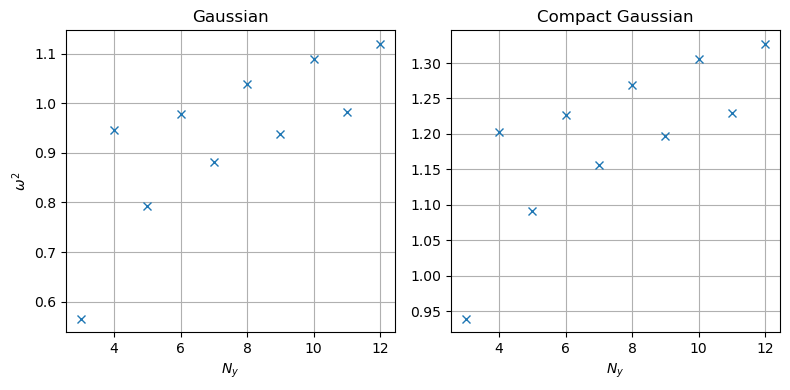

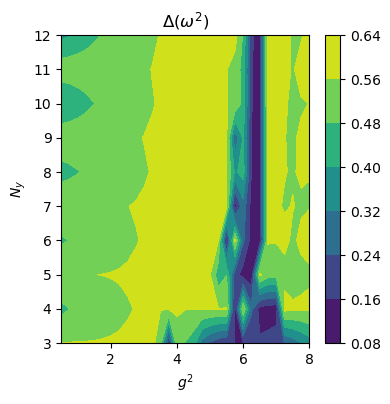

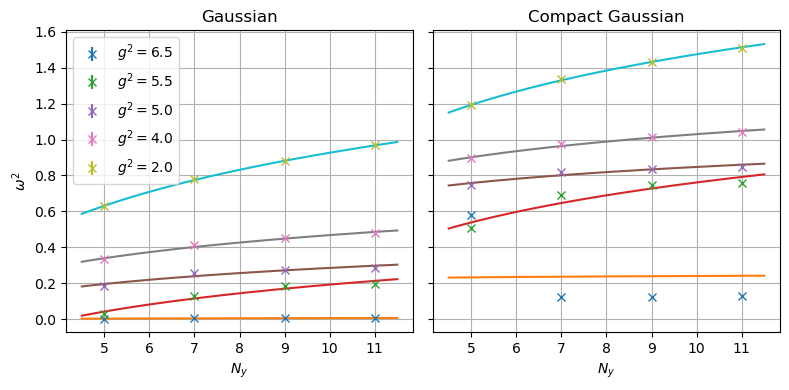

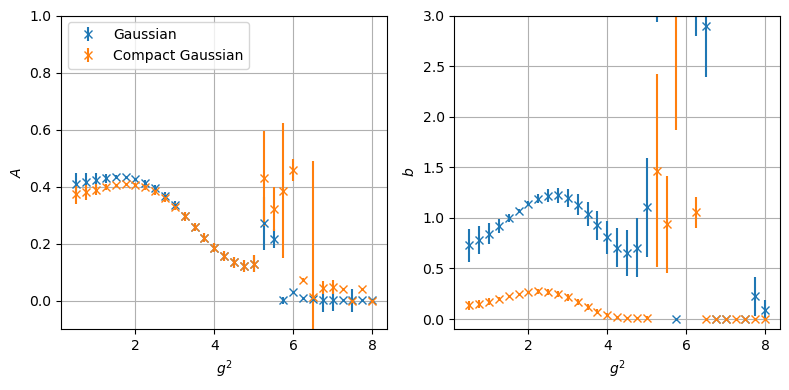

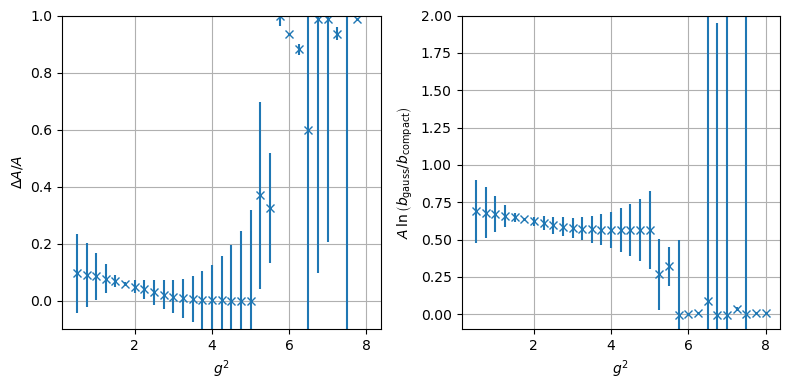

In [15]:
Ny_even = Ny % 2 == 1
Ny_filter = np.logical_and(Ny_even, Ny >= 5)

g2_filter = (np.abs(g2 - 2.0) < 1e-5) | (np.abs(g2 - 4.0) < 1e-5) | (np.abs(g2 - 5.0) < 1e-5) | (np.abs(g2 - 5.5) < 1e-5) | (np.abs(g2 - 6.5) < 1e-5)

def write_w_table(i):
    with open(f"string-params_g2_{round(g2[i], 2)}.tex", "w") as f:
        print(r"\begin{table}[!hb]", file=f)
        print(r"\centering", file=f)
        print(r"\begin{tabular}{llll}", file=f)
        print(r"    $\mathbf{N_y}$ & $\mathbf{A_\mathrm{gauss}}$ & $\mathbf{\omega_\mathrm{gauss}}$ & $\mathbf{c_\mathrm{gauss}}$ \\ \hline", file=f)
    
        for j, _Ny in enumerate(Ny[Ny_filter]):
            print(rf"   {_Ny} & {A[i,j]:fS} & {omega[i,j]:fS} & {c[i,j]:fS} \\", file=f)
    
        print(r"\end{tabular}", file=f)
        print(r"\begin{tabular}{llll}", file=f)
        print(r"    $\mathbf{N_y}$ & $\mathbf{A_\mathrm{compact}}$ & $\mathbf{\omega_\mathrm{compact}}$ & $\mathbf{c_\mathrm{compact}}$ \\ \hline", file=f)
    
        for j, _Ny in enumerate(Ny[Ny_filter]):
            print(rf"   {_Ny} & {A_compact[i,j]:fS} & {omega_compact[i,j]:fS} & {c_compact[i,j]:fS} \\", file=f)
    
        print(r"\end{tabular}", file=f)
        print(r"\caption{String cross section parameters $A$, $\omega$ and $c$ for $g^2=" + str(round(g2[i], 2)) + "$}", file=f)
        print(r"\end{table}", file=f)

for i in range(len(g2)):
    write_w_table(i)

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].set_title(r"Gaussian")
ax[1].set_title(r"Compact Gaussian")
ax[0].set_xlabel(r"$N_y$")
ax[1].set_xlabel(r"$N_y$")
ax[0].set_ylabel(r"$\omega^2$")
ax[0].grid()
ax[1].grid()
ax[0].errorbar(Ny, unp.nominal_values(omega[-7]), unp.std_devs(omega[-7]), fmt='x')
ax[1].errorbar(Ny, unp.nominal_values(omega_compact[-7]), unp.std_devs(omega_compact[-7]), fmt='x')
fig.tight_layout()
fig.savefig("string-width.png", dpi=300)

X, Y = np.meshgrid(g2, Ny)

plt.figure(figsize=(4,4))
plt.title(r"$\Delta\left(\omega^2\right)$")
plt.xlabel(r"$g^2$")
plt.ylabel(r"$N_y$")
plt.contourf(X, Y, unp.nominal_values(omega_compact**2 - omega**2).T)
plt.colorbar()
plt.savefig("omega-diff.png", dpi=300)

def string_width(x, A, b):
    return A * np.log(x/b)

A_fit = []
b_fit = []
A_fit_compact = []
b_fit_compact = []

for i, _g2 in enumerate(g2):
    try:
        opt, cov = sp.optimize.curve_fit(string_width, Ny[Ny_filter], unp.nominal_values(omega[i][Ny_filter]**2), p0=(0, 1), bounds=([0, 0], [1, np.inf]))
        chi2 = np.sum((unp.nominal_values(omega[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt))**2 / unp.std_devs(omega[i][Ny_filter]**2)**2) / (len(Ny[Ny_filter]) - len(opt))
        uopt = correlated_values(opt, cov)
    except RuntimeError:
        uopt = (0, 0)
        chi2 = 0

    try:
        opt_compact, cov_compact = sp.optimize.curve_fit(string_width, Ny[Ny_filter], unp.nominal_values(omega_compact[i][Ny_filter]**2), p0=(0, 1), bounds=([0, 0], [1, np.inf]))
        chi2_compact = np.sum((unp.nominal_values(omega_compact[i][Ny_filter]) - string_width(Ny[Ny_filter], *opt_compact))**2 / unp.std_devs(omega_compact[i][Ny_filter]**2)**2) / (len(Ny[Ny_filter]) - len(opt_compact))
        uopt_compact = correlated_values(opt_compact, cov_compact)
    except RuntimeError:
        uopt_compact = (0, 0)
        chi2_compact = 0

    print(f"g2={round(_g2, 2)}: Gaussian: A={uopt[0]}, b={uopt[1]}, chi2={round(chi2, 2)}, Compact Gaussian: A={uopt_compact[0]}, b={uopt_compact[1]}, chi2={round(chi2_compact, 2)}")
    A_fit.append(uopt[0])
    b_fit.append(uopt[1])
    A_fit_compact.append(uopt_compact[0])
    b_fit_compact.append(uopt_compact[1])

A_fit = np.array(A_fit)
b_fit = np.array(b_fit)
A_fit_compact = np.array(A_fit_compact)
b_fit_compact = np.array(b_fit_compact)

with open("rough-string-params.tex", "w") as f:
    print(r"\begin{table}[!hb]", file=f)
    print(r"\centering", file=f)
    print(r"\begin{tabular}{lllll}", file=f)
    print(r"    $\mathbf{g^2}$ & $\mathbf{A_\mathrm{gauss}}$ & $\mathbf{b_\mathrm{gauss}}$ & $\mathbf{A_\mathrm{compact}}$ & $\mathbf{b_\mathrm{compact}}$ \\ \hline", file=f)

    for i, _g2 in enumerate(g2):
        print(rf"   {round(_g2, 2)} & {A_fit[i]:fS} & {b_fit[i]:fS} & {(A_fit_compact[i] if not isinstance(A_fit_compact[i], int) else ufloat(0,0)):fS} & {(b_fit_compact[i] if not isinstance(b_fit_compact[i], int) else ufloat(0,0)):fS} \\", file=f)

    print(r"\end{tabular}", file=f)
    print(r"\caption{Rough string width parameters $A$ and $b$}", file=f)
    print(r"\end{table}", file=f)

fig, ax = plt.subplots(1, 2, figsize=(8,4), sharey=True)
ax[0].set_title(r"Gaussian")
ax[1].set_title(r"Compact Gaussian")
ax[0].set_xlabel(r"$N_y$")
ax[1].set_xlabel(r"$N_y$")
ax[0].set_ylabel(r"$\omega^2$")
ax[0].grid()
ax[1].grid()

for i, _g2 in enumerate(g2):
    if not g2_filter[i]:
        continue

    ax[0].errorbar(Ny[Ny_filter], unp.nominal_values(omega[i][Ny_filter]**2), unp.std_devs(omega[i][Ny_filter]**2), fmt='x', label=fr"$g^2={round(_g2, 2)}$")
    ax[1].errorbar(Ny[Ny_filter], unp.nominal_values(omega_compact[i][Ny_filter]**2), unp.std_devs(omega_compact[i][Ny_filter]**2), fmt='x', label=fr"$g^2={round(_g2, 2)}$")

    Ny_theo = np.linspace(4.5, 11.5, 1000)
    ax[0].plot(Ny_theo, string_width(Ny_theo, A_fit[i].nominal_value, b_fit[i].nominal_value))
    ax[1].plot(Ny_theo, string_width(Ny_theo, A_fit_compact[i].nominal_value, b_fit_compact[i].nominal_value))

ax[0].legend()
#ax[1].legend()
fig.tight_layout()
fig.savefig("omega.png", dpi=300)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].set_xlabel(r"$g^2$")
ax[0].set_ylabel(r"$A$")
ax[1].set_xlabel(r"$g^2$")
ax[1].set_ylabel(r"$b$")
ax[0].grid()
ax[1].grid()

ax[0].errorbar(g2, unp.nominal_values(A_fit), unp.std_devs(A_fit), fmt='x', label="Gaussian")
ax[0].errorbar(g2, unp.nominal_values(A_fit_compact), unp.std_devs(A_fit_compact), fmt='x', label="Compact Gaussian")
ax[1].errorbar(g2, unp.nominal_values(b_fit), unp.std_devs(b_fit), fmt='x', label="Gaussian")
ax[1].errorbar(g2, unp.nominal_values(b_fit_compact), unp.std_devs(b_fit_compact), fmt='x', label="Compact Gaussian")
ax[0].set_ylim(-0.1, 1)
ax[1].set_ylim(-0.1, 3)
ax[0].legend(loc="upper left")
#ax[1].legend(loc="lower left")

fig.tight_layout()
fig.savefig("string-params.png", dpi=300)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].set_xlabel(r"$g^2$")
ax[0].set_ylabel(r"$\Delta A/A$")
ax[1].set_xlabel(r"$g^2$")
ax[1].set_ylabel(r"$A\,\ln\left(b_\mathrm{gauss}/b_\mathrm{compact}\right)$")
ax[0].grid()
ax[1].grid()

ax[0].errorbar(g2, unp.nominal_values(np.abs(A_fit-A_fit_compact)/(A_fit_compact+1e-10)), unp.std_devs(np.abs(A_fit-A_fit_compact)/(A_fit_compact+1e-10)), fmt='x')
ax[1].errorbar(g2, unp.nominal_values(A_fit*unp.log(b_fit/(b_fit_compact+1e-10))), unp.std_devs(A_fit*unp.log(b_fit/(b_fit_compact+1e-10))), fmt='x')
ax[0].set_ylim(-0.1, 1)
ax[1].set_ylim(-0.1, 2)

fig.tight_layout()
fig.savefig("string-params-diff.png", dpi=300)
print(A_fit*unp.log(b_fit/(b_fit_compact+1e-10)))